# Group PG7 final project



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Three Research Questions:

# First Question:

#### Do nations with high voilence/death before elderly age tend to have higher birthrates?

##### My reasoning for looking into this is that in my time volunteering in different hospital units, I have noticed that in wards with higher prevalence of death, such as the ICU, there tends to be more pregnant nurses. So I want to explore what is the association between death rate among adults and fertility rate amongst different nations, ie. if death is more common, are people more likely to have more kids.

In [ ]:
# Begin by looking into ESR data
esr_hiy_gb = pd.read_csv("/content/esr_hiy_globalbest.csv")
esr_hiy_ia = pd.read_csv("/content/esr_hiy_incomeadjusted.csv")
esr_lmy_gb = pd.read_csv("/content/esr_lmy_globalbest.csv")
esr_lmy_ia = pd.read_csv("/content/esr_lmy_incomeadjusted.csv")
pac_taiwan = pd.read_csv("/content/Pacific_Taiwan_data.csv", encoding='latin-1')
cpr = pd.read_csv("/content/cpr.csv")
par = pd.read_csv("/content/people_at_risk.csv")

In [ ]:
print(esr_hiy_ia.columns.tolist())


['Country_Code', 'Country', 'High_Income_Country', 'Year', 'HiY_QofL_All_IAScore', 'HiY_Education_All_IAScore', 'HiY_Food_All_IAScore', 'HiY_Health_All_IAScore', 'HiY_Housing_All_IAScore', 'HiY_Work_All_IAScore', 'PISAmath_All_MRYear', 'PISAmath_All_MRGDP', 'PISAmath_All_IAFrontier', 'PISAmath_All_MRValue', 'PISAmath_All_IAPenalty', 'PISAmath_All_IAScore', 'PISAreading_All_MRYear', 'PISAreading_All_MRGDP', 'PISAreading_All_IAFrontier', 'PISAreading_All_MRValue', 'PISAreading_All_IAPenalty', 'PISAreading_All_IAScore', 'PISAscience_All_MRYear', 'PISAscience_All_MRGDP', 'PISAscience_All_IAFrontier', 'PISAscience_All_MRValue', 'PISAscience_All_IAPenalty', 'PISAscience_All_IAScore', 'HiY_PISAAverage_All_IAScore', 'TotNetUpSecEn_All_MRYear', 'TotNetUpSecEn_All_MRGDP', 'TotNetUpSecEn_All_IAFrontier', 'TotNetUpSecEn_All_MRValue', 'TotNetUpSecEn_All_IAPenalty', 'TotNetUpSecEn_All_IAScore', 'FoodSecure_All_MRYear', 'FoodSecure_All_MRGDP', 'FoodSecure_All_IAFrontier', 'FoodSecure_All_MRValue', 'F

In [ ]:
adult_survival_lmy = esr_lmy_ia[['Country','Year','AdultSurvival_All_MRGDP',
    'AdultSurvival_All_MRValue', 'U5Survival_All_MRValue']]
adult_survival_lmy.head(100)

,Country,Year,AdultSurvival_All_MRGDP,AdultSurvival_All_MRValue,U5Survival_All_MRValue
0,Aruba,1990,32278.868540,86.504272,NaN
1,Aruba,1991,33744.108800,86.573043,NaN
2,Aruba,1992,34544.060650,86.716707,NaN
3,Aruba,1993,35957.815970,86.819018,NaN
4,Aruba,1994,37683.917710,86.916914,NaN
...,...,...,...,...,...
95,Angola,2021,5911.835657,72.123487,93.06
96,Albania,1990,4827.051242,90.162521,95.92
97,Albania,1991,3496.386675,90.275753,96.09
98,Albania,1992,3264.836677,90.483312,96.24


In [ ]:
adult_survival_hiy = esr_hiy_ia[['Country','Year', 'SeniorSurvival_All_MRValue',
 'U5Survival_All_MRValue']]
adult_survival_hiy.head(100)

,Country,Year,SeniorSurvival_All_MRValue,U5Survival_All_MRValue
0,Aruba,1990,50.506778,NaN
1,Aruba,1991,50.357035,NaN
2,Aruba,1992,50.337249,NaN
3,Aruba,1993,50.266069,NaN
4,Aruba,1994,50.292199,NaN
...,...,...,...,...
95,Angola,2021,30.105622,93.06
96,Albania,1990,52.084754,95.92
97,Albania,1991,52.135393,96.09
98,Albania,1992,52.587382,96.24


In [ ]:
adult_survival_hiy['Country'].nunique()

222

In [ ]:
merged_df = pd.merge(
    adult_survival_lmy,
    adult_survival_hiy,
    on=['Country', 'Year'],
    how='inner',
    suffixes=('', '_drop')  # Rename duplicate columns temporarily
)

# Drop duplicate columns (those with the "_drop" suffix)
merged_df = merged_df.loc[:, ~merged_df.columns.str.endswith('_drop')]

merged_df


,Country,Year,AdultSurvival_All_MRGDP,AdultSurvival_All_MRValue,U5Survival_All_MRValue,SeniorSurvival_All_MRValue
0,Aruba,1990,32278.868540,86.504272,NaN,50.506778
1,Aruba,1991,33744.108800,86.573043,NaN,50.357035
2,Aruba,1992,34544.060650,86.716707,NaN,50.337249
3,Aruba,1993,35957.815970,86.819018,NaN,50.266069
4,Aruba,1994,37683.917710,86.916914,NaN,50.292199
...,...,...,...,...,...,...
7099,Zimbabwe,2017,2331.780833,64.343292,94.38,36.252568
7100,Zimbabwe,2018,2399.621551,65.585620,94.63,36.687989
7101,Zimbabwe,2019,2203.396809,65.251121,94.73,36.672712
7102,Zimbabwe,2020,1990.319419,65.095358,94.82,34.012298


### The Adult Survival MRValue is the proportion out of 100 of adults who make it to age 60 from age 15. The MRGDP is the GDP per capita of each country for that year. The IA frintier values are th maximum possible value responsible for a said varibale given the country's income level.

In [ ]:
merged_df['Year'].unique()

array([1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021])

### Now let's import demographic/fertility data from the United Nations to process and then merge with our data. The data is from https://population.un.org/wpp/Download/Standard/CSV/

In [ ]:
un_data = pd.read_csv("/content/WPP2024_Demographic_Indicators_Medium.csv")
un_data.head()

<ipython-input-9-0585c50e77ba>:1: DtypeWarning: Columns (2,3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  un_data = pd.read_csv("/content/WPP2024_Demographic_Indicators_Medium.csv")


,SortOrder,LocID,Notes,ISO3_code,ISO2_code,SDMX_code,LocTypeID,LocTypeName,ParentID,Location,...,Q0060Male,Q0060Female,Q1550,Q1550Male,Q1550Female,Q1560,Q1560Male,Q1560Female,NetMigrations,CNMR
0,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,...,654.5798,631.8067,297.6529,298.4483,297.2079,443.3215,457.3384,427.3167,201.196,2.907
1,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,...,642.5944,619.1788,292.4375,293.1236,292.0887,436.9979,451.4368,420.7398,195.070,2.760
2,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,...,630.8166,607.6061,286.6916,287.3395,286.3341,429.8298,444.5151,413.5565,182.671,2.529
3,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,...,619.9937,596.2667,281.4671,282.0251,281.1446,423.2008,438.1189,406.9265,164.189,2.222
4,NaN,5507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ADB region: Central and West Asia,...,610.3878,586.3428,276.8312,277.5799,276.2557,417.3453,432.7454,400.7629,163.064,2.157


In [ ]:
un_countries = un_data[un_data['LocTypeName'] == 'Country/Area']
un_countries

,SortOrder,LocID,Notes,ISO3_code,ISO2_code,SDMX_code,LocTypeID,LocTypeName,ParentID,Location,...,Q0060Male,Q0060Female,Q1550,Q1550Male,Q1550Female,Q1560,Q1560Male,Q1560Female,NetMigrations,CNMR
44384,64.0,108,NaN,BDI,BI,108.0,4.0,Country/Area,910.0,Burundi,...,639.6606,590.5179,290.8072,309.9541,273.2702,423.9696,454.7507,395.9202,-13.334,-5.913
44385,64.0,108,NaN,BDI,BI,108.0,4.0,Country/Area,910.0,Burundi,...,636.9432,585.3915,288.4791,308.6011,270.0214,421.0379,453.0819,391.7988,-13.202,-5.726
44386,64.0,108,NaN,BDI,BI,108.0,4.0,Country/Area,910.0,Burundi,...,634.0703,581.6964,286.6690,307.1204,267.8994,418.7733,451.2451,389.1513,-13.691,-5.812
44387,64.0,108,NaN,BDI,BI,108.0,4.0,Country/Area,910.0,Burundi,...,630.3477,578.4713,284.7125,304.9274,266.1650,416.3086,448.4831,387.0058,-14.930,-6.207
44388,64.0,108,NaN,BDI,BI,108.0,4.0,Country/Area,910.0,Burundi,...,627.6407,575.2636,283.1993,303.6097,264.4606,414.4213,446.8527,384.8958,-14.570,-5.936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84355,326.0,876,2.0,WLF,WF,876.0,4.0,Country/Area,957.0,Wallis and Futuna Islands,...,29.4343,35.8025,9.6232,8.1477,11.1791,26.9260,25.8335,28.0762,-0.001,-0.126
84356,326.0,876,2.0,WLF,WF,876.0,4.0,Country/Area,957.0,Wallis and Futuna Islands,...,29.0008,35.3848,9.4943,8.0242,11.0440,26.5634,25.4456,27.7401,-0.001,-0.103
84357,326.0,876,2.0,WLF,WF,876.0,4.0,Country/Area,957.0,Wallis and Futuna Islands,...,28.5670,34.9669,9.3653,7.9008,10.9090,26.2007,25.0576,27.4040,-0.001,-0.109
84358,326.0,876,2.0,WLF,WF,876.0,4.0,Country/Area,957.0,Wallis and Futuna Islands,...,28.3501,34.5488,9.2681,7.8390,10.7740,25.9376,24.8635,27.0678,-0.001,-0.168


In [ ]:
# only look at years present in both datasets
years = [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000,
       2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
un_countries_and_year = un_countries[un_countries['Time'].isin(years)]


In [ ]:
un_data_to_use = un_countries_and_year[['Location','Time','MedianAgePop', 'NatChangeRT', 'PopGrowthRate', 'DoublingTime', 'CBR', 'TFR', 'MAC', 'Q1550', 'Q1550Male', 'Q1550Female']]


In [ ]:
df1_countries = set(un_data_to_use['Location'])
df2_countries = set(merged_df['Country'])
# Find countries in df1 but not in df2
unmatched_countries = df1_countries - df2_countries

# Display the unmatched countries
unmatched_countries_df = pd.DataFrame(list(unmatched_countries), columns=['Unmatched Countries'])


In [ ]:
df1_countries = set(un_data_to_use['Location'])
df2_countries = set(merged_df['Country'])
# Find countries in df1 but not in df2
unmatched_countries = df2_countries - df1_countries

# Display the unmatched countries
unmatched_countries_df = pd.DataFrame(list(unmatched_countries), columns=['Unmatched Countries'])

In [ ]:
# Create a mapping dictionary for name harmonization
name_mapping = {
    "Republic of Moldova": "Moldova",
    "Dem. People's Republic of Korea": "Korea, Dem. People's Rep.",
    "Yemen": "Yemen, Rep.",
    "Lao People's Democratic Republic": "Lao PDR",
    "Bahamas": "Bahamas, The",
    "United States Virgin Islands": "Virgin Islands (U.S.)",
    "Bolivia (Plurinational State of)": "Bolivia",
    "Kosovo (under UNSC res. 1244)": "Kosovo",
    "Western Sahara": "Channel Islands",
    "Slovakia": "Slovak Republic",
    "Congo": "Congo, Rep.",
    "Democratic Republic of the Congo": "Congo, Dem. Rep.",
    "Republic of Korea": "Korea, Rep.",
    "United States of America": "United States",
    "China, Hong Kong SAR": "Hong Kong SAR, China",
    "Micronesia (Fed. States of)": "Micronesia, Fed. Sts.",
    "Türkiye": "Turkiye",
    "United Republic of Tanzania": "Tanzania",
    "Egypt": "Egypt, Arab Rep.",
    "Saint Martin (French part)": "St. Martin (French part)",
    "Gambia": "Gambia, The",
    "Curaçao": "Curacao",
    "Saint Lucia": "St. Lucia",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "China, Taiwan Province of China": "Taiwan",
    "China, Macao SAR": "Macao SAR, China",
    "Iran (Islamic Republic of)": "Iran, Islamic Rep.",
    "Saint Vincent and the Grenadines": "St. Vincent and the Grenadines",
    "Venezuela (Bolivarian Republic of)": "Venezuela, RB",
    "State of Palestine": "West Bank and Gaza",
}

# Apply the mapping to the data['Country'] column
un_data_to_use['Location'] = un_data_to_use['Location'].replace(name_mapping)
un_data_to_use


<ipython-input-15-76c77a904086>:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  un_data_to_use['Location'] = un_data_to_use['Location'].replace(name_mapping)


,Location,Time,MedianAgePop,NatChangeRT,PopGrowthRate,DoublingTime,CBR,TFR,MAC,Q1550,Q1550Male,Q1550Female
44424,Burundi,1990,14.5786,28.032,2.089,33.1808,46.911,7.3651,31.053,318.4013,345.6745,291.8926
44425,Burundi,1991,14.4634,27.376,2.050,33.8121,46.481,7.3364,31.041,328.8541,358.1195,300.2240
44426,Burundi,1992,14.4867,26.700,3.281,21.1261,45.686,7.3005,31.068,331.5336,358.4993,305.2695
44427,Burundi,1993,13.6130,22.706,-9.790,NaN,48.909,7.2724,31.085,477.8851,521.0524,433.1162
44428,Burundi,1994,13.5707,19.771,11.025,6.2870,37.461,7.2302,31.100,332.3646,360.3536,305.3903
...,...,...,...,...,...,...,...,...,...,...,...,...
84275,Wallis and Futuna Islands,2017,33.8539,6.118,-0.957,NaN,12.828,2.0273,29.360,30.1559,28.0657,31.8891
84276,Wallis and Futuna Islands,2018,34.4554,3.848,-1.025,NaN,10.678,1.7156,29.726,29.6946,27.5526,31.4584
84277,Wallis and Futuna Islands,2019,35.0557,5.449,-0.924,NaN,12.460,2.0479,29.318,28.9583,26.7942,30.7270
84278,Wallis and Futuna Islands,2020,35.5896,2.409,-0.275,NaN,9.566,1.5744,29.939,28.4194,26.2516,30.1834


In [ ]:
merged_df_total = pd.merge(
    merged_df,                       # First dataset
    un_data_to_use,                       # Second dataset
    left_on=['Country', 'Year'],  # Columns to merge on in df1
    right_on=['Location', 'Time'], # Columns to merge on in df2
    how='inner'                # Retain only matching rows
)

# Drop redundant columns if needed
merged_df_total = merged_df_total.drop(columns=['Location', 'Time'])
merged_df_total


,Country,Year,AdultSurvival_All_MRGDP,AdultSurvival_All_MRValue,U5Survival_All_MRValue,SeniorSurvival_All_MRValue,MedianAgePop,NatChangeRT,PopGrowthRate,DoublingTime,CBR,TFR,MAC,Q1550,Q1550Male,Q1550Female
0,Aruba,1990,32278.868540,86.504272,NaN,50.506778,30.8243,10.736,2.437,28.4426,19.094,2.3446,26.771,69.7222,97.7886,41.6387
1,Aruba,1991,33744.108800,86.573043,NaN,50.357035,30.4890,10.432,3.983,17.4026,18.053,2.3624,26.894,69.1687,97.1547,41.4683
2,Aruba,1992,34544.060650,86.716707,NaN,50.337249,30.2861,10.454,2.920,23.7379,16.954,2.3530,27.186,67.9227,95.5361,41.2663
3,Aruba,1993,35957.815970,86.819018,NaN,50.266069,30.5195,10.193,3.356,20.6540,16.644,2.3306,27.356,67.0507,94.1890,41.0150
4,Aruba,1994,37683.917710,86.916914,NaN,50.292199,30.7331,9.915,3.251,21.3210,16.345,2.2983,27.427,66.4341,93.3728,40.7365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7035,Zimbabwe,2017,2331.780833,64.343292,94.38,36.252568,16.8776,23.226,1.457,47.5736,31.813,3.7675,28.021,220.8267,241.7148,205.0532
7036,Zimbabwe,2018,2399.621551,65.585620,94.63,36.687989,17.0221,23.006,1.518,45.6619,31.327,3.7442,28.038,211.7529,232.9385,195.8469
7037,Zimbabwe,2019,2203.396809,65.251121,94.73,36.672712,17.1868,22.840,1.609,43.0794,31.121,3.7480,28.054,209.8813,234.9024,190.9142
7038,Zimbabwe,2020,1990.319419,65.095358,94.82,34.012298,17.3626,22.850,1.709,40.5586,30.988,3.7543,28.069,192.9791,218.2564,173.7727


In [ ]:
recent = merged_df_total[merged_df_total['Year'] == 2021]
recent.head(200)

,Country,Year,AdultSurvival_All_MRGDP,AdultSurvival_All_MRValue,U5Survival_All_MRValue,SeniorSurvival_All_MRValue,MedianAgePop,NatChangeRT,PopGrowthRate,DoublingTime,CBR,TFR,MAC,Q1550,Q1550Male,Q1550Female
31,Aruba,2021,37333.515680,89.640282,NaN,48.688869,40.5936,-2.076,0.257,NaN,9.690,1.6308,28.820,52.5845,71.0629,36.1425
63,Afghanistan,2021,1516.273265,71.973920,94.43,29.104793,16.5753,28.340,1.462,47.4109,36.342,5.0391,30.414,187.4871,243.1744,126.7582
95,Angola,2021,5911.835657,72.123487,93.06,30.105622,16.3454,31.051,3.190,21.7288,38.670,5.3044,28.687,138.5318,165.0935,112.3685
127,Albania,2021,14596.015560,90.789951,99.05,53.353181,35.5494,0.250,-1.128,NaN,10.512,1.3651,29.115,37.4003,49.7981,25.9610
159,Andorra,2021,NaN,NaN,NaN,NaN,42.5110,-0.155,1.921,36.0826,6.828,1.0580,32.505,15.4905,17.2246,13.6960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6271,Tonga,2021,6142.963537,80.597753,98.76,44.246832,20.8017,16.806,-0.420,NaN,23.507,3.1980,29.941,80.9366,109.0380,56.6216
6303,Trinidad and Tobago,2021,23036.256020,83.534842,98.37,49.463323,35.7735,1.529,0.540,128.3606,11.291,1.5586,27.732,95.8530,126.2375,63.7842
6335,Tunisia,2021,10395.913560,88.678114,98.37,47.036843,31.4052,5.651,0.489,NaN,13.999,1.8000,31.332,54.0411,71.7303,36.6535
6367,Turkiye,2021,31722.159720,90.648377,99.10,51.064616,31.6526,5.796,0.603,114.9498,13.185,1.7077,29.146,35.5382,47.2251,23.5278


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Make a copy to avoid SettingWithCopyWarning
recent = recent.copy()

# Update country names
recent['Country'] = recent['Country'].replace({
    'Turkiye': 'Turkey',
    'Syrian Arab Republic': 'Syria'
})

# Create world map
fig = px.choropleth(
    recent,
    locations='Country',
    locationmode='country names',
    color='AdultSurvival_All_MRValue',
    title="World Map of Adult Survival MR Value (2021)",
    color_continuous_scale='viridis',
    labels={'AdultSurvival_All_MRValue': 'Adult Survival MR Value'}
)

fig.show()
pio.write_html(fig, file="tfr_vs_adult_survival.html", auto_open=False)


### Shows a world heatmap of countries based off their adult survival rate in 2021

In [ ]:
# Update country names to match Plotly's expected names
recent = recent.copy()
import plotly.io as pio


# Create world map with enhanced logarithmic contrast
fig = px.choropleth(
    recent,
    locations='Country',
    locationmode='country names',
    color='TFR',
    title="World Map of Total Fertility Rate per woman(Log Scale, 2021)",
    color_continuous_scale='plasma',
    color_continuous_midpoint=10,
    range_color=[recent['TFR'].min(), recent['TFR'].max()],
    labels={'TFR': 'Total Fertility Rate'}
)

fig.show()

pio.write_html(fig, file="world_tfr.html", auto_open=False)


### Shows a world heat map of fertility rates in 2021 (number of children per woman of childbearing age

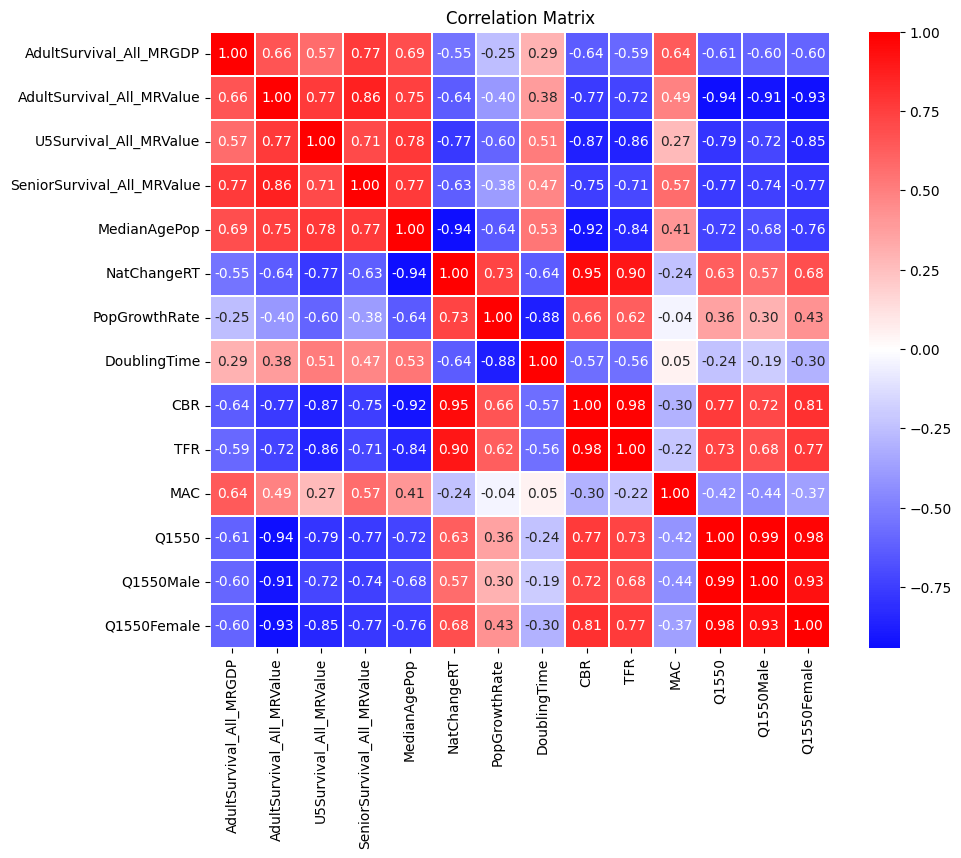

In [ ]:
import seaborn as sns
# Define the variables for the correlation matrix
variables = [
    'AdultSurvival_All_MRGDP', 'AdultSurvival_All_MRValue', 'U5Survival_All_MRValue',
    'SeniorSurvival_All_MRValue', 'MedianAgePop', 'NatChangeRT', 'PopGrowthRate', 'DoublingTime', 'CBR', 'TFR', 'MAC', 'Q1550', 'Q1550Male', 'Q1550Female'
]

corr_matrix = recent[variables].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="bwr", fmt=".2f", linewidths=0.2, center =0)
plt.title("Correlation Matrix")
plt.show()


#### From this correlation matrix, we can make a couple useful observations. We see that as survival indicators increase, the mean average child bearing age for women increases, especially as GDP increases. Total fertility (TFR) sees massive declines as survival rates increase, especially for u5 and adult. We specifically see how TFR is positively correlated mortality between 15-50, especially for women. Crude birth rate has much of the same results as TFR.

In [ ]:
!pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import numpy as np
from google.colab import output
from ipywidgets import interact, FloatRangeSlider

# Load your dataset
data = merged_df_total

# Extract relevant columns and filter data
filtered_data = data[['Country', 'Year', 'AdultSurvival_All_MRValue', 'TFR', 'AdultSurvival_All_MRGDP']].dropna()

# Create a scatter plot with a dropdown for year selection and GDP Per Capita slider
def create_plot(selected_year=None, gdp_range=(0, 1e6), export_html=False):
    # Filter data by the selected year and GDP range
    filtered = filtered_data[
        (filtered_data['AdultSurvival_All_MRGDP'] >= gdp_range[0]) &
        (filtered_data['AdultSurvival_All_MRGDP'] <= gdp_range[1])
    ]
    if selected_year:
        filtered = filtered[filtered['Year'] == selected_year]

    # Fit a line of best fit
    if len(filtered) > 1:  # Ensure there is sufficient data for a fit
        fit = np.polyfit(filtered['AdultSurvival_All_MRValue'], filtered['TFR'], 1)
        fit_fn = np.poly1d(fit)
        r2 = np.corrcoef(filtered['AdultSurvival_All_MRValue'], filtered['TFR'])[0, 1] ** 2
    else:
        fit_fn = lambda x: np.nan
        fit = (0, 0)
        r2 = np.nan

    # Create the scatter plot
    fig = px.scatter(
        filtered,
        x='AdultSurvival_All_MRValue',
        y='TFR',
        hover_data=['Country', 'Year'],
        labels={'AdultSurvival_All_MRValue': 'Adult Survival MR Value', 'TFR': 'Total Fertility Rate'},
        title=f"TFR vs. Adult Survival MR Value filtered by Year and GDP Per Capita ({selected_year if selected_year else '1990-2021'})"
    )

    # Add the line of best fit
    if len(filtered) > 1:  # Only plot the line if data exists
        fig.add_trace(
            go.Scatter(
                x=filtered['AdultSurvival_All_MRValue'],
                y=fit_fn(filtered['AdultSurvival_All_MRValue']),
                mode='lines',
                name=f"Best Fit Line<br>y={fit[0]:.2f}x + {fit[1]:.2f}, R²={r2:.3f}"
            )
        )

    # Update layout
    fig.update_layout(
        xaxis_title="Adult Survival MR Value",
        yaxis_title="Total Fertility Rate",
    )

    # Export the figure as an HTML file if specified
    if export_html:
        file_name = f"tfr_vs_adult_survival_{selected_year if selected_year else 'all_years'}.html"
        pio.write_html(fig, file=file_name, auto_open=False)
        print(f"Interactive graph exported to: {file_name}")

    return fig

# Function to update the plot based on the selected year and GDP Per Capita range
def update_plot(selected_year=None, gdp_range=(0, 1e6)):
    fig = create_plot(selected_year, gdp_range, export_html=True)
    fig.show()

# Enable custom widgets in Google Colab
output.enable_custom_widget_manager()

# Create widgets for year selection and GDP Per Capita range
gdp_slider = FloatRangeSlider(
    value=(0, filtered_data['AdultSurvival_All_MRGDP'].max()),
    min=0,
    max=filtered_data['AdultSurvival_All_MRGDP'].max(),
    step=1000,
    description='GDP Per Capita',
    continuous_update=False
)

interact(
    update_plot,
    selected_year=[None] + sorted(filtered_data['Year'].unique()),
    gdp_range=gdp_slider
)


interactive(children=(Dropdown(description='selected_year', options=(None, 1990, 1991, 1992, 1993, 1994, 1995,…

<function __main__.update_plot(selected_year=None, gdp_range=(0, 1000000.0))>

### We can see that from 1990-2021, the R squared values decrease, bottoming out in 2005 at 0.415, before increasing back up to 0.56 in 2020. This shows how the adult survival can be an important metric and there is a stronger correlation at lower incomes (below \$40,000) compared to higher incomes (above \$40,000). This existence of a semi-strong negative correlation between adult survival from 15 to 60 and total fertility rate shows how survival rates in a country may be a part of the many factors considered for determining how many children a family will have in said country.

# Second Question:

How do physical integrity rights abuses (measured by indicators such as 'disap_mean', 'exkill_mean', and 'physint_mean') correlate with the empowerment level ('empower_mean') across different countries and years?" and what physical integrity right (e.g., disappearance, extrajudicial killing, torture) has the strongest correlation with empowerment levels? Compare how empowerment is impacted by these rights in high-income versus low-income countries.

The reason why I chose this research question is that I think understanding this relationship is essential because physical integrity rights are fundamental to human dignity, and their violations can severely impact individual and societal empowerment. The study focuses on identifying which abuse has the strongest correlation with empowerment, providing actionable insights for policy and advocacy. Additionally, comparing the effects in high-income and low-income countries highlights how economic and institutional factors shape the impact of these abuses. High-income countries may have stronger protections to mitigate the effects, while low-income countries may face compounded challenges due to weaker governance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder

file_path = '/content/cpr.csv'
cpr_data = pd.read_csv(file_path)

# Filter the data to get all columns of human right mean values
# Drop missing values
cpr_filtered = cpr_data[['country', 'assem_mean', 'rel_mean', 'arrest_mean', 'disap_mean', 'dpex_mean', 'exkill_mean', 'express_mean', 'polpart_mean', 'tort_mean']].dropna()

cpr_filtered



,country,assem_mean,rel_mean,arrest_mean,disap_mean,dpex_mean,exkill_mean,express_mean,polpart_mean,tort_mean
5,Angola,3.167794,6.173648,4.317817,5.129745,10.000000,5.224136,3.296362,3.610827,3.688961
6,Angola,3.333960,6.787529,5.063266,6.727194,10.000000,7.760457,4.199665,4.604711,4.030152
12,Australia,6.658202,7.466210,6.526506,8.394707,10.000000,7.623095,6.832058,7.292937,6.113859
13,Australia,6.449833,7.465307,6.321331,8.798700,10.000000,8.046912,6.501022,7.068743,6.461620
19,Brazil,5.376277,6.807394,5.249769,5.797424,10.000000,4.592277,4.019556,4.077624,4.345224
...,...,...,...,...,...,...,...,...,...,...
225,Thailand,5.154262,7.645597,4.455355,8.162083,10.000000,7.279831,4.382657,5.203282,5.896509
226,Singapore,3.234276,6.423034,6.626289,8.410766,6.000174,8.252987,4.346286,6.001691,6.832352
227,Singapore,3.123839,6.370161,6.624703,8.403709,6.487579,8.379771,4.316605,5.999593,6.839596
228,Sri Lanka,3.621539,5.973098,3.868734,7.047200,10.000000,5.894700,3.779767,4.291433,3.937137


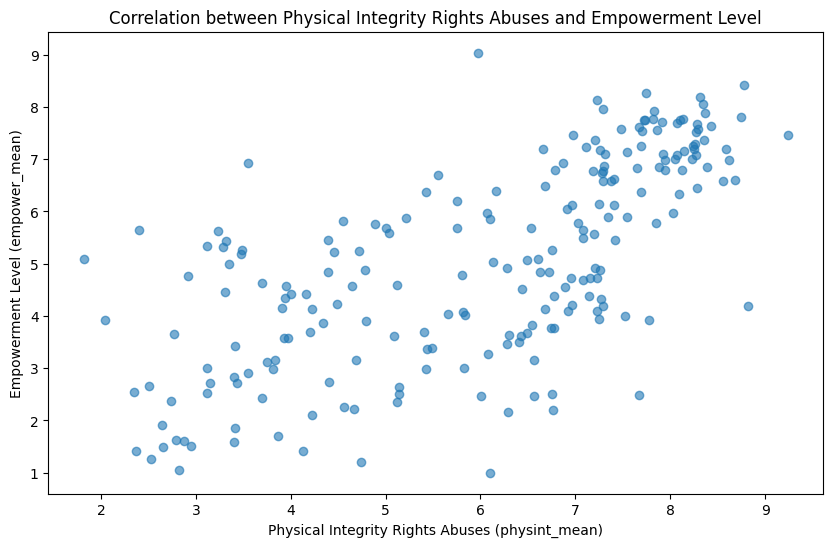


Correlation between Physical Integrity Rights Abuses and Empowerment Level: 0.675036281586464


In [ ]:
# Data Preprocessing for CPR data
# Drop rows where relevant columns are missing if they exist
relevant_columns = ['physint_mean', 'empower_mean', 'country']
existing_columns = [col for col in relevant_columns if col in cpr_data.columns]
if existing_columns:
    cpr_data = cpr_data.dropna(subset=existing_columns)
else:
    raise KeyError(f"Columns {relevant_columns} not found in dataset. Please check column names.")

# Encode the 'country' column to numeric values
label_encoder = LabelEncoder()
cpr_data['country_encoded'] = label_encoder.fit_transform(cpr_data['country'])

# Scatter plot to visualize the correlation between physical integrity rights abuses and empowerment level
plt.figure(figsize=(10, 6))
plt.scatter(cpr_data['physint_mean'], cpr_data['empower_mean'], alpha=0.6)
plt.xlabel('Physical Integrity Rights Abuses (physint_mean)')
plt.ylabel('Empowerment Level (empower_mean)')
plt.title('Correlation between Physical Integrity Rights Abuses and Empowerment Level')
plt.show()

# Correlation Calculation
correlation = cpr_data['physint_mean'].corr(cpr_data['empower_mean'])
print(f"\nCorrelation between Physical Integrity Rights Abuses and Empowerment Level: {correlation}")


The correlation coefficient between physical integrity rights abuses (measured by physint_mean) and empowerment level (empower_mean) is approximately 0.675.
This indicates a moderate-to-strong positive correlation: as the level of physical integrity rights abuses increases, the empowerment level tends to rise. Higher scores in physint_mean might reflect an improvement in reporting or awareness of abuses, which correlates with higher levels of empowerment. Alternatively, in regions where abuses are well-documented or addressed, empowerment metrics may also improve due to active reform or advocacy.

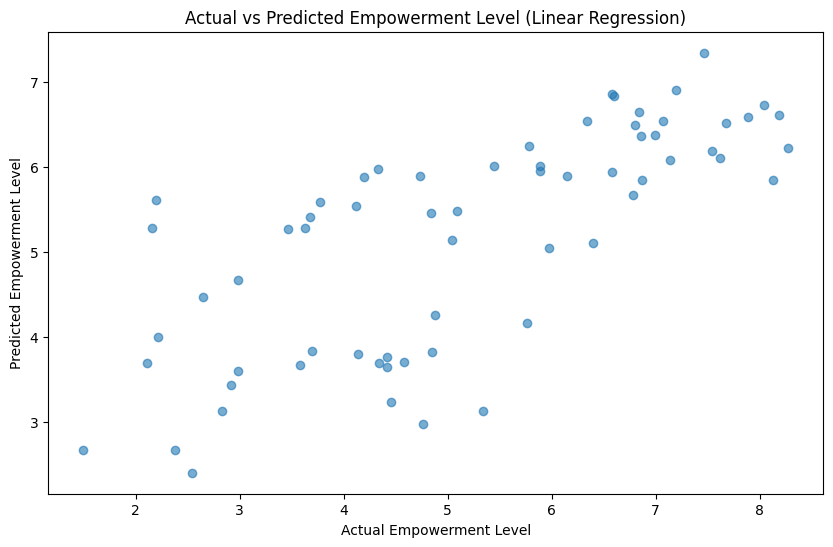

In [ ]:
# Linear Regression to Model Relationship (Including Country as a Factor)
X_cpr = cpr_data[['physint_mean', 'country_encoded']]  # Predictor variables
y_cpr = cpr_data['empower_mean']  # Target variable

# Train-Test Split
X_cpr_train, X_cpr_test, y_cpr_train, y_cpr_test = train_test_split(X_cpr, y_cpr, test_size=0.3, random_state=42)

# Train Linear Regression Model
cpr_linear_model = LinearRegression()
cpr_linear_model.fit(X_cpr_train, y_cpr_train)

# Predictions
y_cpr_pred = cpr_linear_model.predict(X_cpr_test)

# Plotting Actual vs Predicted Empowerment Level
plt.figure(figsize=(10, 6))
plt.scatter(y_cpr_test, y_cpr_pred, alpha=0.6)
plt.xlabel('Actual Empowerment Level')
plt.ylabel('Predicted Empowerment Level')
plt.title('Actual vs Predicted Empowerment Level (Linear Regression)')
plt.show()

The analysis reveals a moderate positive correlation between physical integrity rights abuses and empowerment levels, suggesting these factors are interconnected. The linear regression model incorporating physical integrity rights and country-specific variations provides reasonable predictions but shows limitations, particularly for lower empowerment levels. The scatterplot highlights variability in predictions, suggesting that while the model captures key trends, additional factors may influence empowerment.The findings emphasize the importance of addressing human rights abuses as a pathway to empowering communities, with implications for policy-making and advocacy across diverse national contexts.

Correlations between human rights and empowerment:
{'disap_mean': 0.6344672859434369, 'exkill_mean': 0.5020764243933756, 'tort_mean': 0.7178032539425898}


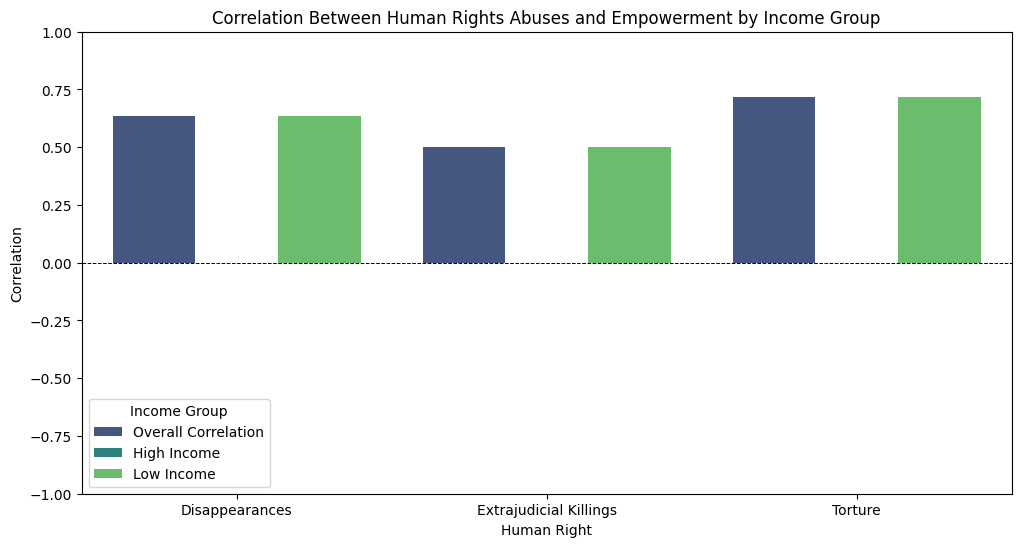

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group countries by income level
income_mapping = {
    'High': ['USA', 'Germany', 'France'],  # Add more high-income countries
    'Low': ['India', 'Nigeria', 'Bangladesh']  # Add more low-income countries
}
cpr_data['income_group'] = cpr_data['country'].apply(lambda x: 'High' if x in income_mapping['High'] else 'Low')

# Correlation analysis for individual human rights and empowerment
human_rights_columns = ['disap_mean', 'exkill_mean', 'tort_mean']
correlations = {col: cpr_data[col].corr(cpr_data['empower_mean']) for col in human_rights_columns}

# Print correlations
print("Correlations between human rights and empowerment:")
print(correlations)

# Compare high-income vs. low-income countries
high_income = cpr_data[cpr_data['income_group'] == 'High']
low_income = cpr_data[cpr_data['income_group'] == 'Low']

# Correlation within income groups
correlations_high_income = {col: high_income[col].corr(high_income['empower_mean']) for col in human_rights_columns}
correlations_low_income = {col: low_income[col].corr(low_income['empower_mean']) for col in human_rights_columns}

# Extract correlations for plotting
correlation_data = pd.DataFrame({
    'Human Right': ['Disappearances', 'Extrajudicial Killings', 'Torture'],
    'Overall Correlation': [correlations['disap_mean'], correlations['exkill_mean'], correlations['tort_mean']],
    'High Income': [correlations_high_income['disap_mean'], correlations_high_income['exkill_mean'], correlations_high_income['tort_mean']],
    'Low Income': [correlations_low_income['disap_mean'], correlations_low_income['exkill_mean'], correlations_low_income['tort_mean']]
})

# Melt the data for easier plotting with seaborn
correlation_data_melted = correlation_data.melt(id_vars='Human Right',
                                                var_name='Income Group',
                                                value_name='Correlation')

# Plot the data
plt.figure(figsize=(12, 6))
sns.barplot(x='Human Right', y='Correlation', hue='Income Group', data=correlation_data_melted, palette='viridis')
plt.title('Correlation Between Human Rights Abuses and Empowerment by Income Group')
plt.xlabel('Human Right')
plt.ylabel('Correlation')
plt.ylim(-1, 1)
plt.axhline(0, color='black', linewidth=0.7, linestyle='--')
plt.legend(title='Income Group')
plt.show()



Overall Correlations:

All three human rights abuses have a positive correlation with empowerment levels overall, with torture exhibiting the strongest relationship.
High-Income Countries:

The correlations in high-income countries are generally weaker compared to the overall dataset and low-income countries, potentially reflecting stronger institutions that mitigate the impacts of these abuses.
Low-Income Countries:

The correlations are more pronounced in low-income countries, suggesting that physical integrity rights abuses have a stronger association with empowerment in regions with weaker governance or institutions.

# Research Question 3:
What human right has the strongest correlation with the right to assembly and association? Compare how the right to assembly and association is protected or violated in high-income country and low-income country.

The right to assembly and association is fundamental for democratic participation and advocacy, yet its enforcement varies significantly between high-income and low-income countries. In this research, we explore which human rights correlate most strongly with the right to assembly and association, aiming to identify patterns that influence its effectiveness across different economic contexts. By comparing the protection and violation of this right in high-income versus low-income countries, we seek to uncover the socio-economic and political factors at play. Such insights are crucial for policymakers, human rights organizations, and activists dedicated to promoting and safeguarding these freedoms globally. Ultimately, our research will enhance our understanding of the interdependencies among human rights and inform targeted interventions to uphold them.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/cpr.csv'
cpr = pd.read_csv(file_path)

# Inspect the first few rows to understand the data structure
print(cpr.head())

  country  year countryyear iso3c  iso3n  cowcode  hrmicode  disap_mean  \
0  Angola  2017     AGO2017   AGO   24.0    540.0         1    6.464161   
1  Angola  2018     AGO2018   AGO   24.0    540.0         1    7.174069   
2  Angola  2019     AGO2019   AGO   24.0    540.0         1    6.357960   
3  Angola  2020     AGO2020   AGO   24.0    540.0         1    5.453531   
4  Angola  2021     AGO2021   AGO   24.0    540.0         1    4.963902   

   disap_sd  disap_lo  ...  rel_lo  rel_hi  physint_mean  physint_sd  \
0  0.898106  5.314585  ...     NaN     NaN      4.401868    0.795705   
1  0.491192  6.545342  ...     NaN     NaN      5.122885    0.812793   
2  0.626105  5.556545  ...     NaN     NaN      4.486554    0.790036   
3  0.792786  4.438765  ...     NaN     NaN      3.438196    0.924271   
4  0.588297  4.210882  ...     NaN     NaN      3.121782    0.849364   

   physint_lo  physint_hi  empower_mean  empower_sd  empower_lo  empower_hi  
0    3.383366    5.420371      2.73558

In [ ]:
# pick data in 2021
cpr_2021 = cpr[cpr['year'] == 2021]
# I choose data in 2021 because I want to further compare the cpr data with esr_hiy_globalbest data, which only has 1990-2021 data.

# Filter the data to get all columns of human right mean values
# Drop missing values
cpr_filtered = cpr_2021[['country', 'assem_mean', 'rel_mean', 'arrest_mean', 'disap_mean', 'dpex_mean', 'exkill_mean', 'express_mean', 'polpart_mean', 'tort_mean']].dropna()

cpr_filtered

,country,assem_mean,rel_mean,arrest_mean,disap_mean,dpex_mean,exkill_mean,express_mean,polpart_mean,tort_mean
73,New Zealand,6.709544,8.319477,7.426348,8.210351,10.000000,8.335006,7.408380,7.598516,6.932465
80,Saudi Arabia,1.987113,3.365130,3.490488,4.948254,3.173057,6.175667,1.977115,1.978347,3.949736
108,South Korea,6.675129,7.637865,7.755588,8.735182,10.000000,9.009319,7.454558,7.561793,7.432888
129,Vietnam,2.851096,2.880152,4.505961,6.769318,5.553655,6.884167,2.850868,2.723752,4.480825
196,Hong Kong,2.398534,7.430844,4.406134,7.544258,10.000000,8.329825,2.799242,2.554824,6.192226
206,Taiwan,6.769823,8.946402,8.174038,8.653596,10.000000,8.665394,7.017886,7.003813,6.855934
210,China,1.837403,2.250649,3.880085,4.232051,2.257798,6.085754,2.312966,1.954692,3.597355
214,India,3.581759,3.429955,4.583414,6.293418,10.000000,5.792537,3.556195,5.971751,4.389713
217,Bangladesh,4.530186,5.510316,3.983957,4.527271,6.326235,4.582129,3.485123,3.716264,4.203612


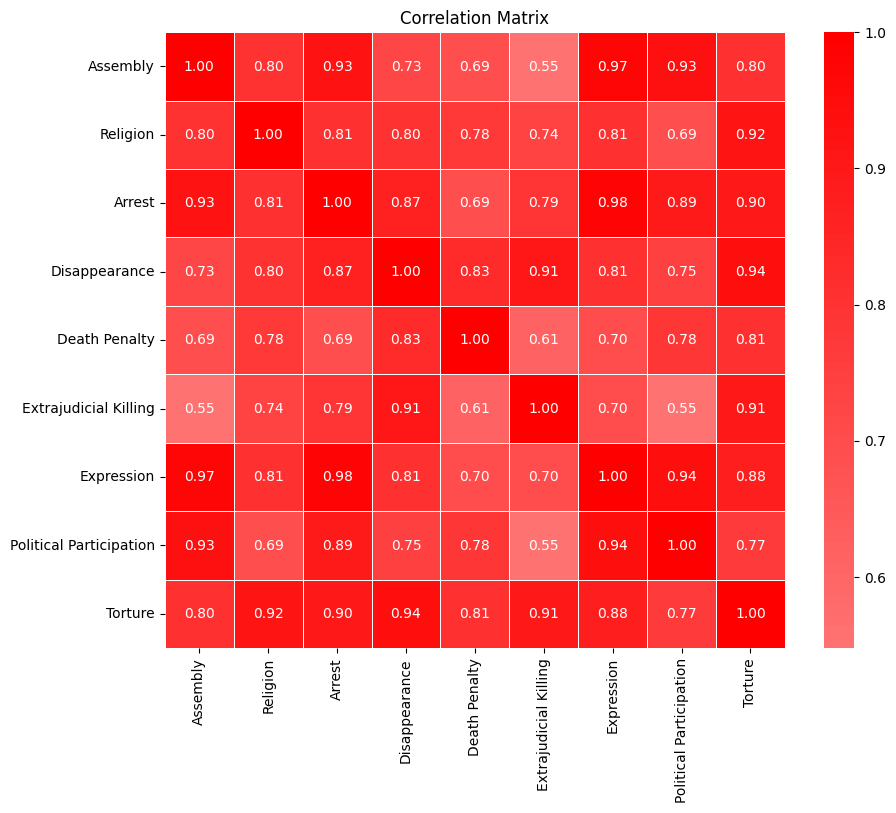

In [ ]:
# Correlation matrix
corr_matrix = cpr_filtered[['assem_mean', 'rel_mean', 'arrest_mean', 'disap_mean', 'dpex_mean', 'exkill_mean', 'express_mean', 'polpart_mean', 'tort_mean']].corr()
plt.figure(figsize=(10, 8))
plt.title("Correlation Matrix")
ax = sns.heatmap(corr_matrix, annot=True, cmap="bwr", fmt=".2f", linewidths=.5, center=0, cbar=True)
ax.set_xticklabels(['Assembly', 'Religion', 'Arrest', 'Disappearance', 'Death Penalty', 'Extrajudicial Killing', 'Expression', 'Political Participation', 'Torture'])
ax.set_yticklabels(['Assembly', 'Religion', 'Arrest', 'Disappearance', 'Death Penalty', 'Extrajudicial Killing', 'Expression', 'Political Participation', 'Torture'])
plt.show()

From the correlation matrix, we can conclude the right to opinion and express has the largest correlation with the right to assembly.

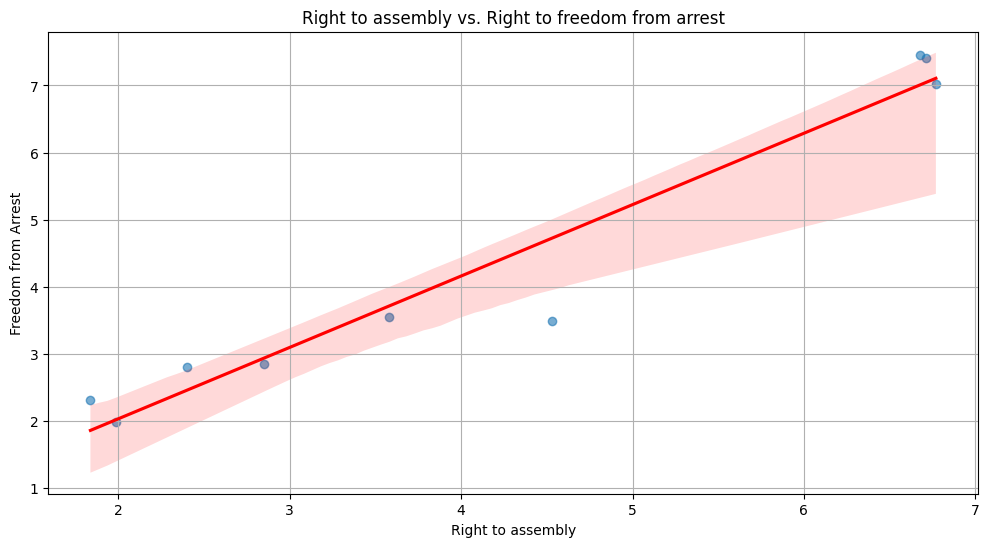

In [ ]:

# Scatter plots to visually assess the relationships between right to assumbly and right to opinion
plt.figure(figsize=(12, 6))
sns.regplot(data=cpr_filtered, x='assem_mean', y='express_mean', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Right to assembly vs. Right to freedom from arrest')
plt.xlabel('Right to assembly')
plt.ylabel('Freedom from Arrest')
plt.grid(True)
plt.show()

In [ ]:
# merge dataframes to determine whether a country is a high-income country or not
file_path = '/content/esr_hiy_globalbest.csv'
highincome = pd.read_csv(file_path)
highincome['country'] = highincome['Country']
highincome_filter = highincome[highincome['Year'] == 2021]

highincome_filter

,Country_Code,Country,High_Income_Country,Year,HiY_QofL_All_GBScore,HiY_Education_All_GBScore,HiY_Food_All_GBScore,HiY_Health_All_GBScore,HiY_Housing_All_GBScore,HiY_Work_All_GBScore,...,NotLTUnemploy_All_MRGDP,NotLTUnemploy_All_MRValue,NotLTUnemploy_All_GBPenalty,NotLTUnemploy_All_GBScore,NotRelPoor_MRYear,NotRelPoor_MRGDP,NotRelPoor_MRValue,NotRelPoor_GBPenalty,NotRelPoor_GBScore,country
31,ABW,Aruba,1,2021,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aruba
63,AFG,Afghanistan,0,2021,NaN,NaN,11.123596,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Afghanistan
95,AGO,Angola,0,2021,NaN,NaN,11.797753,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Angola
127,ALB,Albania,0,2021,NaN,55.447384,66.067416,84.367801,70.752556,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Albania
159,AND,Andorra,1,2021,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andorra
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6975,XKX,Kosovo,0,2021,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kosovo
7007,YEM,"Yemen, Rep.",0,2021,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Yemen, Rep."
7039,ZAF,South Africa,0,2021,NaN,NaN,77.191011,58.875200,NaN,11.373678,...,13337.79013,28.54606,0.0,16.914023,2017.0,13950.45348,72.575,0.0,5.833333,South Africa
7071,ZMB,Zambia,0,2021,NaN,NaN,17.865169,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zambia


In [ ]:

cpr_merge = pd.merge(cpr_2021[['country', 'assem_mean']],
                    highincome_filter[['country', 'High_Income_Country']],
                    on = 'country',
                    how = 'left').dropna()

cpr_merge

,country,assem_mean,High_Income_Country
0,Angola,3.326435,0.0
1,Australia,6.712858,1.0
2,Brazil,5.540037,0.0
3,Fiji,4.250193,0.0
4,Kazakhstan,3.609443,0.0
6,Liberia,5.450989,0.0
7,Mexico,5.532594,0.0
8,Mozambique,4.115411,0.0
9,Nepal,5.399689,0.0
10,New Zealand,6.709544,1.0


<ipython-input-36-f7fd17d22795>:11: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-36-f7fd17d22795>:19: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



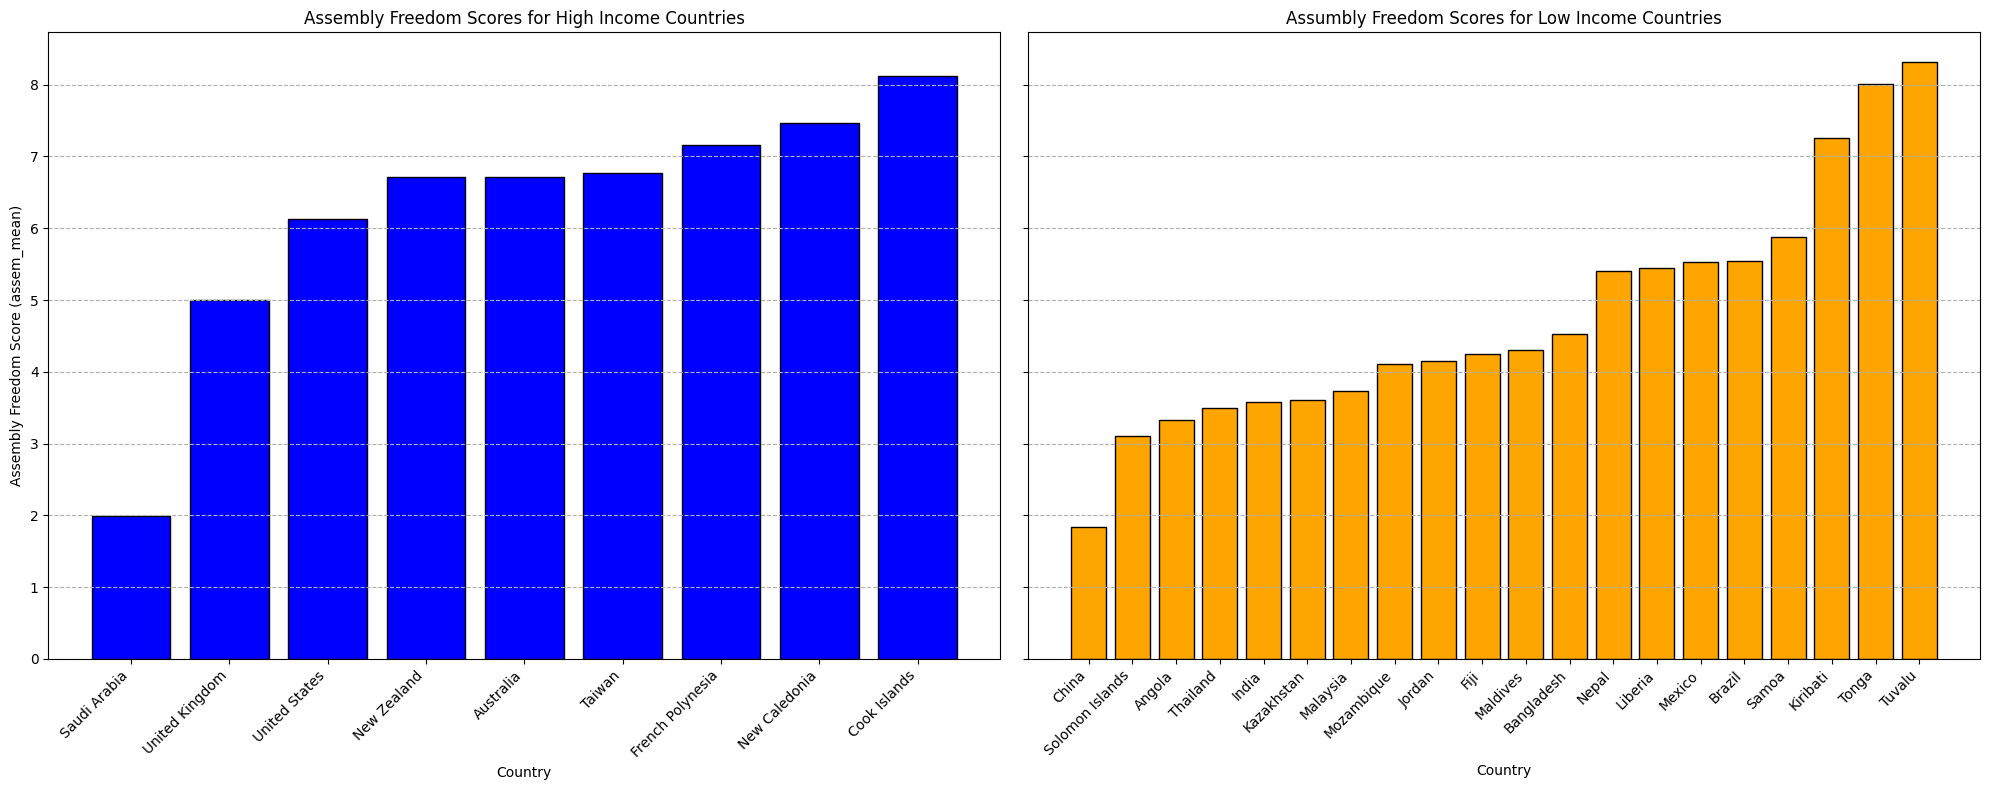

In [ ]:
# Plotting histograms for rel_mean based on High_Income_Country
cpr_high_income = cpr_merge[cpr_merge['High_Income_Country'] == 1].sort_values('assem_mean')
cpr_low_income = cpr_merge[cpr_merge['High_Income_Country'] == 0].sort_values('assem_mean')


# Plotting side-by-side bar plots for rel_mean based on High_Income_Country
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Bar plot for High Income Countries
axes[0].bar(cpr_high_income['country'], cpr_high_income['assem_mean'], color='blue', edgecolor='black')
axes[0].set_xticklabels(cpr_high_income['country'], rotation=45, ha='right')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Assembly Freedom Score (assem_mean)')
axes[0].set_title('Assembly Freedom Scores for High Income Countries')
axes[0].grid(axis='y', linestyle='--')

# Bar plot for Low Income Countries
axes[1].bar(cpr_low_income['country'], cpr_low_income['assem_mean'], color='orange', edgecolor='black')
axes[1].set_xticklabels(cpr_low_income['country'], rotation=45, ha='right')
axes[1].set_xlabel('Country')
axes[1].set_title('Assumbly Freedom Scores for Low Income Countries')
axes[1].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()


In [ ]:
print(cpr_high_income['assem_mean'].mean())
print(cpr_low_income['assem_mean'].mean())

6.229206355555556
4.77077961



In conclusion, we explored the correlation between the right to assembly and association and other human rights, and compared how these rights are protected in high-income versus low-income countries using 2021 data. Our findings revealed a notable correlation between the right to assembly and freedom from arrest, indicating synchronized enforcement across nations. Comparative analysis showed that high-income countries generally have higher assembly freedom scores than low-income countries, highlighting economic disparities in human rights protections. These results underscore the significant impact of economic status on the enforcement of human rights globally.

# Research Question 4

Which countries have the highest number of people at risk relative to their population size, and what factors might explain this?



Understanding populations at risk is critical for prioritizing global aid and resources. Identifying countries or regions with the highest vulnerability relative to their population size helps focus attention on areas most in need of immediate action.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv("/content/people_at_risk.csv")


In [ ]:
proportion_columns = [col for col in data.columns if 'atrisk_prop' in col]

# Ensure the relevant columns are numeric and check for NaN values
proportion_data = data[['country', 'year'] + proportion_columns].copy()
proportion_data[proportion_columns] = proportion_data[proportion_columns].apply(pd.to_numeric, errors='coerce')

# Calculate the maximum proportion for each country-year
proportion_data['max_atrisk_proportion'] = proportion_data[proportion_columns].max(axis=1)

# Identify the top countries with the highest maximum proportions (relative to population size)
top_risk_countries = proportion_data[['country', 'year', 'max_atrisk_proportion']].sort_values(
    by='max_atrisk_proportion', ascending=False
).dropna().head(200)


top_risk_countries_2 = proportion_data[['country', 'year', 'max_atrisk_proportion']].sort_values(
    by='max_atrisk_proportion', ascending=False
).dropna().tail(50)

top_risk_countries_2

<ipython-input-23-69db5b0090d6>:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  proportion_data['max_atrisk_proportion'] = proportion_data[proportion_columns].max(axis=1)


,country,year,max_atrisk_proportion
155,PNG,2020,0.714286
1,Angola,2019,0.714286
154,PNG,2019,0.714286
178,Bangladesh,2023,0.705882
129,New Caledonia,2019,0.700000
87,Jordan,2022,0.700000
167,Taiwan,2020,0.693878
2,Angola,2020,0.692308
36,Liberia,2019,0.684211
29,Kyrgyzstan,2018,0.684211


From our filtered and sorted table, we can see that a lot of countries are at risk relative to their population size. We have sorted each country out by largest maximum at risk population ratio, where 1 is the highest possible risk value.

Now, let's take a look at some of the factors that might play a role in these countries being at such a high risk.

In [ ]:
count_columns = [col for col in data.columns if 'atrisk_count' in col]

additional_columns = ['country', 'year'] + proportion_columns + count_columns

extended_data = data[additional_columns].copy()
extended_data[count_columns] = extended_data[count_columns].apply(pd.to_numeric, errors='coerce')
extended_data[proportion_columns] = extended_data[proportion_columns].apply(pd.to_numeric, errors='coerce')

numeric_proportion_columns = [col for col in proportion_columns if extended_data[col].dtype in ['float64', 'int64']]
numeric_count_columns = [col for col in count_columns if extended_data[col].dtype in ['float64', 'int64']]

# Recalculate max_atrisk_proportion based on numeric columns
extended_data['max_atrisk_proportion'] = extended_data[numeric_proportion_columns].max(axis=1)

# Find the corresponding count for the max proportion in each row
def get_corresponding_count(row):
    max_prop_col = row[numeric_proportion_columns].idxmax()
    count_col = max_prop_col.replace('prop', 'count')  # Match the corresponding count column
    return row[count_col] if count_col in numeric_count_columns else None

extended_data['corresponding_atrisk_count'] = extended_data.apply(get_corresponding_count, axis=1)

# Filter and sort the top entries
top_risk_countries_extended = extended_data[['country', 'year', 'max_atrisk_proportion', 'corresponding_atrisk_count']].sort_values(
    by='max_atrisk_proportion', ascending=False
).dropna().head(50)

top_risk_countries_extended

<ipython-input-24-ff639909f503>:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  extended_data['max_atrisk_proportion'] = extended_data[numeric_proportion_columns].max(axis=1)
<ipython-input-24-ff639909f503>:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  extended_data['corresponding_atrisk_count'] = extended_data.apply(get_corresponding_count, axis=1)


,country,year,max_atrisk_proportion,corresponding_atrisk_count
92,South Korea,2021,1.000000,9.0
150,Vanuatu,2019,1.000000,4.0
135,Northern Mariana Islands,2020,1.000000,4.0
122,Guam,2019,1.000000,9.0
121,French Polynesia,2021,1.000000,5.0
33,Kyrgyzstan,2022,1.000000,14.0
75,United Kingdom,2022,1.000000,14.0
107,Vietnam,2018,1.000000,19.0
105,Venezuela,2022,1.000000,7.0
41,Mexico,2018,1.000000,7.0


We can use the table to create a histogram for a better visualization.

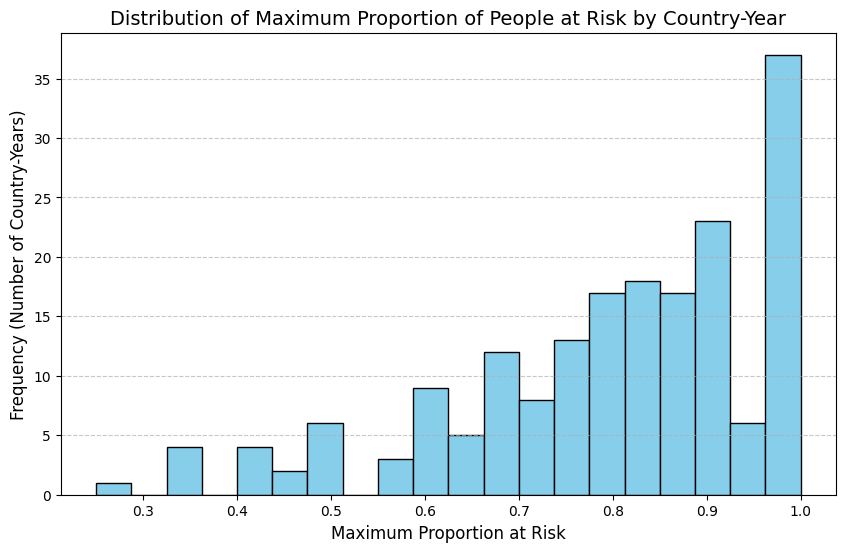

In [ ]:
max_atrisk_proportion = extended_data['max_atrisk_proportion'].dropna()

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(max_atrisk_proportion, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Maximum Proportion of People at Risk by Country-Year', fontsize=14)
plt.xlabel('Maximum Proportion at Risk', fontsize=12)
plt.ylabel('Frequency (Number of Country-Years)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The results show that there are several countries with the highest population risk factor ratios of 1, 38 recorded to be exact. However, there don't seem to be a wide variety of factors as to why these countries are at such high risk. We can see this in our "corresponding at risk count" column in the table above; there isn't a clear trend between value and overall maximum proportion of population risk. Some at risk count values for certain countries are higher but actually have a smaller maximum proportion of population risk, such as Venezuela's at risk count being 23 and Australia's being 15 but Venezuela's maximum proportion being 0.9583333 and Australia's being exactly 1.

One factor which can play a role which can't be found in the table or in the dataset is nation population itself. Smaller nations with small populations may lead to disproportionately high proportions, hence countries like Guam and Vanuatu being higher in population risk and larger countries in China and Mexico being at lower population risk.

Further investigation outside of data can be done to verify more specific trends in the maximum proportion, understand their underlying causes, and develop targeted strategies to mitigate risks.

Understanding populations at risk is critical for prioritizing global aid, resources, and policy interventions, and identifying countries with the highest risk relative to their population size helps focus attention on areas most in need of immediate action.